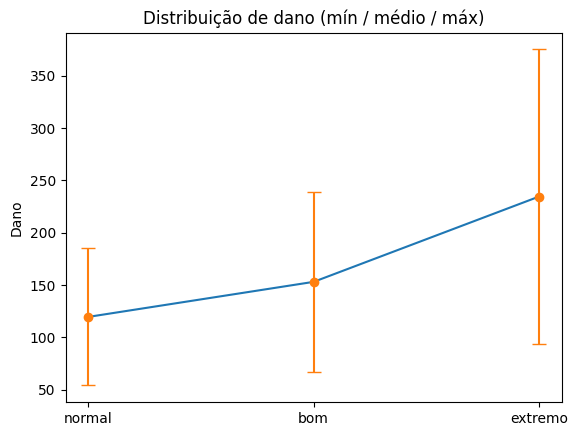

{'normal': (54, 119.5, 185), 'bom': (67, 153.0, 239), 'extremo': (94, 234.5, 375)}


In [5]:
import re
import matplotlib.pyplot as plt

def parse_dice(expr):
    """
    Recebe algo como '5d12 + 45 + 4d20'
    Retorna (min, avg, max)
    """
    parts = re.findall(r'(\d+d\d+|\d+)', expr.replace(" ", ""))
    
    total_min = 0
    total_max = 0
    total_avg = 0
    
    for part in parts:
        if 'd' in part:
            n, d = map(int, part.split('d'))
            total_min += n * 1
            total_max += n * d
            total_avg += n * (d + 1) / 2
        else:
            val = int(part)
            total_min += val
            total_max += val
            total_avg += val

    return total_min, total_avg, total_max


def parse_input(text):
    """
    Extrai os 3 tipos de dano do texto
    """
    pattern = r'Dano (normal|bom|extremo):\s*([^\n]+)'
    matches = re.findall(pattern, text)

    data = {}
    for name, expr in matches:
        data[name] = parse_dice(expr)

    return data


def plot_damage(data):
    labels = []
    avgs = []
    mins = []
    maxs = []

    for key in ["normal", "bom", "extremo"]:
        if key in data:
            mn, avg, mx = data[key]
            labels.append(key)
            avgs.append(avg)
            mins.append(avg - mn)
            maxs.append(mx - avg)

    plt.figure()

    # linha conectando os pontos
    plt.plot(labels, avgs)

    # pontos com barras de erro
    plt.errorbar(labels, avgs, yerr=[mins, maxs], fmt='o', capsize=5)

    plt.ylabel("Dano")
    plt.title("Distribuição de dano (mín / médio / máx)")
    plt.show()


def analyze_damage(text):
    data = parse_input(text)
    plot_damage(data)
    return data


# Exemplo de uso:
text = """
Zirkani - Lâmina maior
Dano normal:   5d12 + 45 + 4d20
Dano bom:        7d12 + 55 + 5d20
Dano extremo: 10d12 + 75 + 9d20
"""

result = analyze_damage(text)
print(result)